In [1]:
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units

In [2]:
#read the enhanced BGS catalogue produced by Augment_BGS_cat.ipynb
dat=Table.read('sdata/BGS_Y3_27Feb2026.fits') 

# Check selection cuts agree with stored meta data of the sample we have read
ca.CheckParametersMatch

<function catalogue_analysis.CheckParametersMatch()>

In [3]:
sdss = Table.read("sdata/sdss5kvn.csv", format="ascii.csv")
sdss.info('stats')

<Table length=5000>
 name     mean        std         min         max    
----- ----------- ----------- ----------- -----------
objid 5.87775e+17 1.03813e+14 5.87723e+17 5.88849e+17
   ra     127.115     37.9468    0.309975     252.041
  dec     24.0382     18.9161    -11.1262     67.8572
    u     19.6184    0.675766     16.5137     25.0349
    g     17.9731    0.556893      15.631     23.8575
    r     17.1382    0.576761     14.7135     21.0887
    i     16.7181    0.587683     14.2405     20.8453
    z     16.4165    0.624408     13.9114     21.1759
  z_1   0.0999962  0.00114285       0.098    0.101999


In [4]:
# Convert to SkyCoord
coords_desi = SkyCoord(ra=dat['RA']*u.deg, dec=dat['DEC']*u.deg)
print('DESI coords set up')

coords_sdss = SkyCoord(ra=sdss['ra']*u.deg, dec=sdss['dec']*u.deg)
print('SDSS coords set up')

# Match each object in cosmos to the nearest in the target and lss table 
idx, sep, _ = coords_sdss.match_to_catalog_sky(coords_desi)


DESI coords set up
SDSS coords set up


Maximum separation of matches to SDSS  s= 1d33m11.41453206s


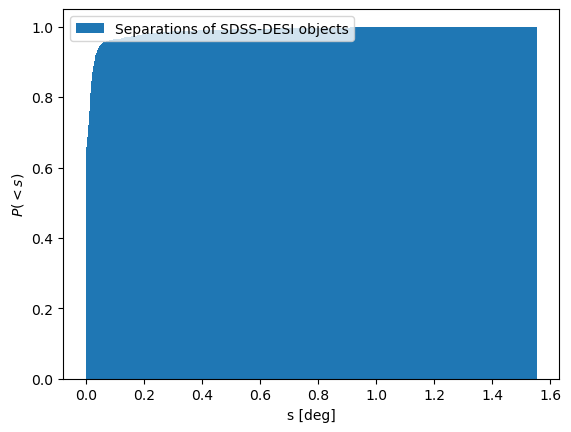

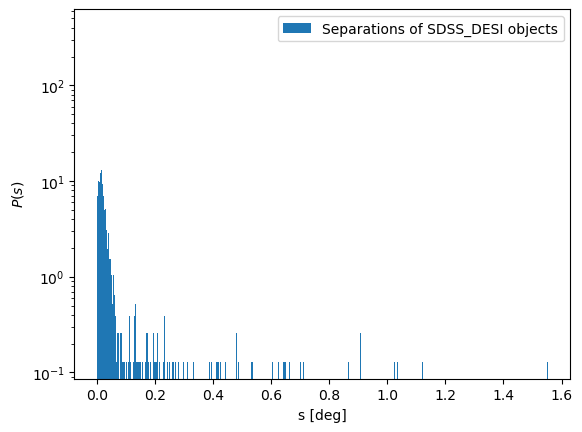

In [5]:
print('Maximum separation of matches to SDSS  s=',max(sep))

#Plot histogram of separation of matches
plt.xlabel('s [deg]')
plt.ylabel('$P(<s)$')
plt.hist(sep,bins=1000,density=True,cumulative=True,label='Separations of SDSS-DESI objects')
#plt.xlim([0,55.0])
#plt.ylim([0.0,15000])
plt.legend()
plt.show()

plt.xlabel('s [deg]')
plt.ylabel('$P(s)$')
plt.hist(sep,bins=1000,density=True,cumulative=False,label='Separations of SDSS_DESI objects')
#plt.xlim([0,813.0])
plt.yscale('log')
#plt.ylim([0.0,0.1])
plt.legend()
plt.show()

In [6]:
matched = (sep.value<1.5/3600.0) # deem matched if within 1.5 arc sec

In [17]:
dat.info('stats')

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213345    0.104259   0.00200098     0.59999
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

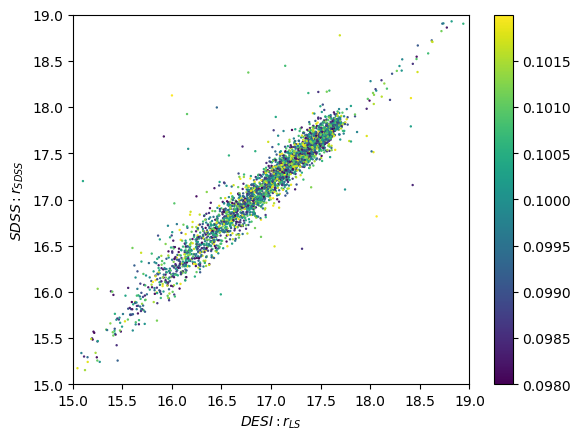

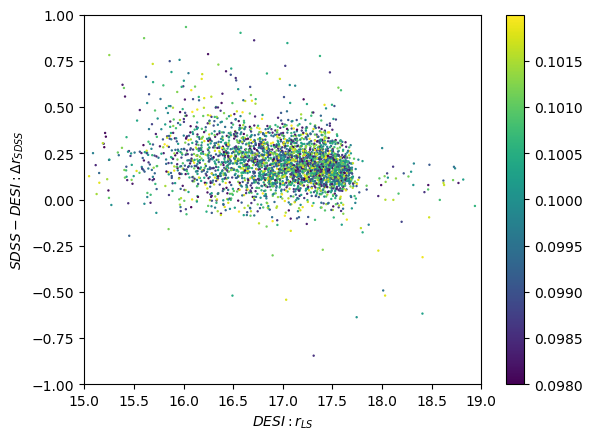

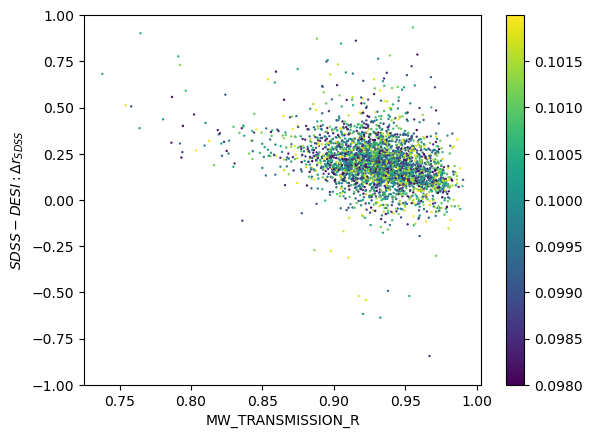

In [21]:
plt.scatter(dat['rmag'][idx][matched],sdss['r'][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)
plt.xlim(15.0,19.0)
plt.ylim(15.0,19.0)
plt.ylabel("$SDSS: r_{SDSS}$")
plt.xlabel("$DESI: r_{LS}$")
plt.colorbar()
plt.show()

plt.scatter(dat['rmag'][idx][matched],sdss['r'][matched]-dat['rmag'][idx][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)
plt.xlim(15.0,19.0)
plt.ylim(-1.0,1.0)
plt.ylabel("$SDSS-DESI: \Delta r_{SDSS}$")
plt.xlabel("$DESI: r_{LS}$")
plt.colorbar()
plt.show()

plt.scatter(dat['MW_TRANSMISSION_R'][idx][matched] ,sdss['r'][matched]-dat['rmag'][idx][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)
#plt.xlim(-1.0,1.0)
plt.ylim(-1.0,1.0)
plt.ylabel("$SDSS-DESI: \Delta r_{SDSS}$")
plt.xlabel("MW_TRANSMISSION_R")
plt.colorbar()
plt.show()

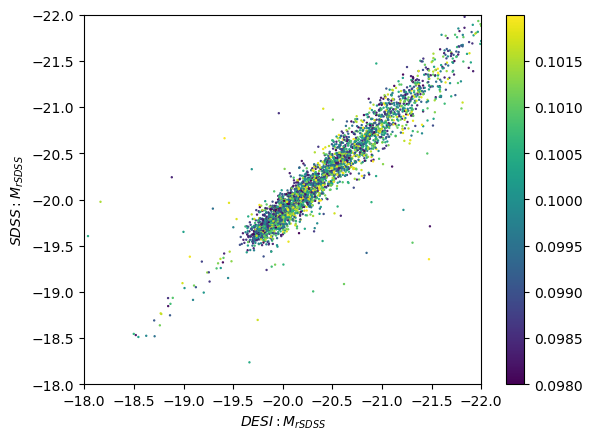

[ 0.14715025  0.17659579  0.22549551  0.20208725  0.17877602  0.18061291
  0.17890233  0.14550964  0.16593991  0.15490793  0.13961841  0.08882691
 -0.00571312  0.06029331  0.00283921 -0.06636107  0.05703699 -0.01421319
         nan -1.56697615]


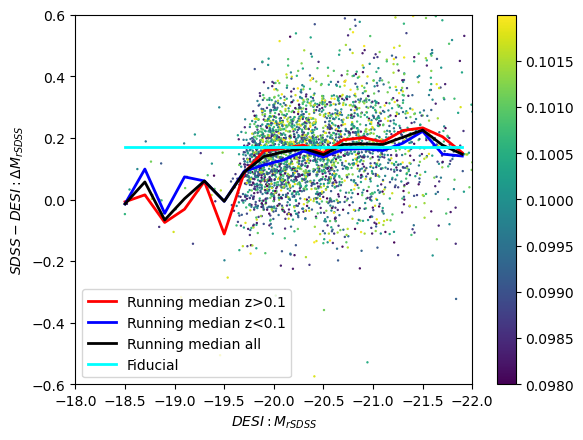

In [16]:
#Now compute SDSS absolute magnitude ignoring k-correction and then compare absolute magintudes
DMOD=25.0+5.0*np.log10(cosmo.luminosity_distance(sdss['z_1']).value)  
sdss['absmag_r']=sdss['r']-DMOD +2.5*np.log10(1.1) #-3.0*(sdss['z_1']-0.1)



plt.scatter(dat['ABSMAG_RP1'][idx][matched],sdss['absmag_r'][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)
plt.xlim(-18.0,-22.0)
plt.ylim(-18.0,-22.0)
plt.ylabel("$SDSS: M_{r SDSS}$")
plt.xlabel("$DESI: M_{r SDSS}$")
plt.colorbar()
plt.show()



plt.scatter(dat['ABSMAG_RP1'][idx][matched],sdss['absmag_r'][matched]-dat['ABSMAG_RP1'][idx][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)

#For subset at z>0.1 and then subset z<0.1 
# --- Compute running median in bins ---

x=dat['ABSMAG_RP1'][idx][matched]
y=sdss['absmag_r'][matched]-dat['ABSMAG_RP1'][idx][matched]

# Choose number of bins (adjust as needed)
nbins = 20  
# Bin edges and centers
bins = np.linspace(-22, -18, nbins + 1)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# Digitize x into bins



highz=(sdss['z_1'][matched]>0.1)
indices = np.digitize(x[highz], bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[highz][indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])
# Plot running median
plt.plot(bin_centers, median_y, color='red', lw=2, label="Running median z>0.1")

lowz=(sdss['z_1'][matched]<0.1)
indices = np.digitize(x[lowz], bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[lowz][indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])

# Plot running median
plt.plot(bin_centers, median_y, color='blue', lw=2, label="Running median z<0.1")




indices = np.digitize(x, bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])
# Plot running median
plt.plot(bin_centers, median_y, color='black', lw=2, label="Running median all")

print(median_y)

# Plot fiducial
median_y=median_y*0.0+0.17
plt.plot(bin_centers, median_y, color='cyan', lw=2, label="Fiducial")

plt.xlim(-18.0,-22.0)
plt.ylim(-0.6,0.6)
plt.ylabel("$SDSS-DESI: \Delta M_{r SDSS}$")
plt.xlabel("$DESI: M_{r SDSS}$")
plt.colorbar()
plt.legend()
plt.show()


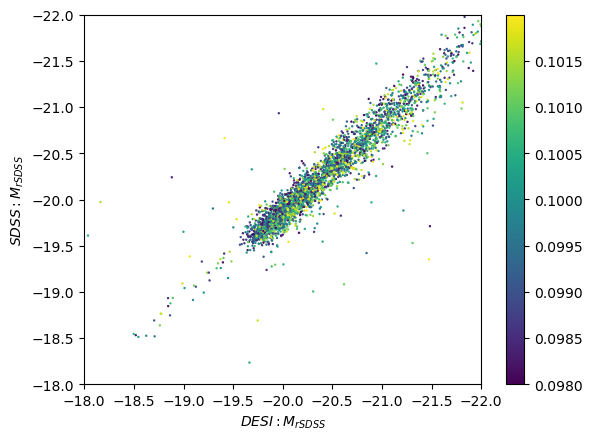

[ 0.14787358  0.17561975  0.22807729  0.20536661  0.17842694  0.18156951
  0.18014854  0.14696919  0.16798985  0.15547066  0.14011627  0.08806412
 -0.0052792   0.06183327  0.00350095 -0.06636288  0.05650992 -0.01320235
         nan -1.57302325]


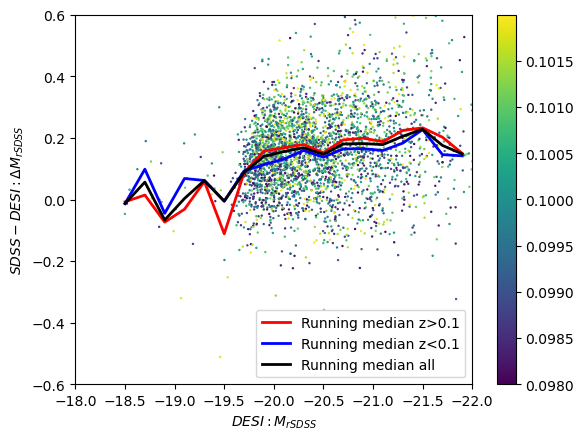

In [11]:
#Now compute SDSS absolute magnitude ignoring k-correction and then compare absolute magintudes
DMOD=25.0+5.0*np.log10(cosmo.luminosity_distance(sdss['z_1']).value)  
sdss['absmag_r']=sdss['r']-DMOD +2.5*np.log10(1.1) 

#For  the matched objects recompute using the DESI redshift
DMOD[matched]=25.0+5.0*np.log10(cosmo.luminosity_distance(dat['Z'][idx][matched]).value)  
sdss['absmag_r'][matched]=sdss['r'][matched]-DMOD[matched] +2.5*np.log10(1.1) 

plt.scatter(dat['ABSMAG_RP1'][idx][matched],sdss['absmag_r'][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)
plt.xlim(-18.0,-22.0)
plt.ylim(-18.0,-22.0)
plt.ylabel("$SDSS: M_{r SDSS}$")
plt.xlabel("$DESI: M_{r SDSS}$")
plt.colorbar()
plt.show()



plt.scatter(dat['ABSMAG_RP1'][idx][matched],sdss['absmag_r'][matched]-dat['ABSMAG_RP1'][idx][matched],c=sdss['z_1'][matched],cmap='viridis',s=2.0, marker='.', linewidths=1)

#For subset at z>0.1 and then subset z<0.1 
# --- Compute running median in bins ---

x=dat['ABSMAG_RP1'][idx][matched]
y=sdss['absmag_r'][matched]-dat['ABSMAG_RP1'][idx][matched]

# Choose number of bins (adjust as needed)
nbins = 20  
# Bin edges and centers
bins = np.linspace(-22, -18, nbins + 1)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# Digitize x into bins



highz=(sdss['z_1'][matched]>0.1)
indices = np.digitize(x[highz], bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[highz][indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])
# Plot running median
plt.plot(bin_centers, median_y, color='red', lw=2, label="Running median z>0.1")

lowz=(sdss['z_1'][matched]<0.1)
indices = np.digitize(x[lowz], bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[lowz][indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])

# Plot running median
plt.plot(bin_centers, median_y, color='blue', lw=2, label="Running median z<0.1")




indices = np.digitize(x, bins)
# Compute median of y in each bin
median_y = np.array([np.median(y[indices == i]) if np.any(indices == i) else np.nan
                     for i in range(1, nbins + 1)])
# Plot running median
plt.plot(bin_centers, median_y, color='black', lw=2, label="Running median all")

print(median_y)

plt.xlim(-18.0,-22.0)
plt.ylim(-0.6,0.6)
plt.ylabel("$SDSS-DESI: \Delta M_{r SDSS}$")
plt.xlabel("$DESI: M_{r SDSS}$")
plt.colorbar()
plt.legend()
plt.show()
